# How do London Airbnb posted prices behave over the calendar?

A study of the **posted (asking) nightly prices** that London Airbnb listings showed for each date
of the year ahead, in the Inside Airbnb snapshot scraped on 5–6 November 2019. Every number is read
from the data or derived from it by a printed rule; no result rests on an assumed, unobserved
parameter.

### Findings in brief

- **About a third of active listings post one price on every date** (flat, 34.9%). The most
  dynamic fifth ("fluid") are the least round-numbered and carry a weekend premium, and fluid
  pricing is **2.4 times as common among professional hosts' listings** as among casual hosts'.
  *(Layer 1 — derived, rule-based; the host comparison is associational.)*
- **Most of the professional gap remains after controlling for the recorded traits.** With room
  type, size, borough, years on Airbnb and superhost status held equal, professional hosts'
  listings are still 13.1 points more likely to vary their prices at all (17.2 before). The gap is
  concentrated among large operators. Listing traits explain little of pricing style, and listings
  of the same host tend to price alike. *(Layer 2 — associational.)*
- **Within the same listing, posted prices are 2.4% higher on Friday and Saturday nights and 11.4%
  higher in the festive week (24 Dec – 1 Jan)** than on the listing's other nights of the same
  month. Beyond those, bank holidays show no detectable extra premium, on the holiday night or on the
  extra night of a long weekend. *(Layer 3 — within-listing difference.)*
- **Professional hosts' listings show about twice the calendar premium:** Fri/Sat +3.0% vs +1.6%, festive
  week +14.5% vs +7.5%. *(Associational: which group shows the larger difference is descriptive.)*

### How the notebook is organized

1. **Data and honesty frame**, then **setup**: the active-listing population and host types.
2. **Layer 1 — pricing texture:** a flat / sticky / fluid typology of each listing's posted-price
   surface, with robustness checks.
3. **Layer 2 — who prices dynamically:** regressions of "do prices vary at all?" and "how
   dynamic?" on host and listing traits, following the professional gap as more is held equal.
4. **Layer 3 — calendar differences:** listing fixed-effects regressions of log posted price on
   weekends, bank holidays and the festive week; then professional vs casual hosts.
5. **Limitations** and **next steps**.

## Data and honesty frame

**Data.** Inside Airbnb London, scraped 2019-11-05/06 (distributed on Kaggle). The calendar file
gives, for every listing and each of the next 365 days, the posted nightly price and an
availability flag: 31,050,094 listing-days for 85,068 listings, 2019-11-05 → 2020-11-04. Prices
are in pounds (the `$` in the raw file is an Inside Airbnb formatting artifact). The calendar's
`adjusted_price` differs from `price` on only 0.65% of rows, so `price` is used throughout.

**The defining caveat.** Every price here is a *posted (asking)* price — the host's or an
algorithm's stated intention as of November 2019 — **not** a transaction price, not demand, not
welfare. This is a **supply-side pricing-behavior study**. The availability flag cannot tell
*blocked* from *booked*, so no occupancy, revenue or booking claim is made anywhere.

### Honesty vocabulary

Every result below carries one of these labels:

| Label | Meaning | Where it applies |
|---|---|---|
| *observed* | read directly from the data | calendar prices, availability flags, listing attributes |
| *derived (rule-based)* | deterministic transform of observed values, definition printed | dynamism index, typology, weekend/holiday flags |
| *associational* | conditional correlation; no causal claim | Layer 2; every professional-vs-casual comparison |
| *within-listing difference* | the same listing's posted price on some dates vs others, after removing everything fixed about the listing and what all listings share in each month; a clean comparison, not the effect of an intervention | Layer 3 core coefficients |

### What we do not claim

- No per-listing "Smart Pricing" / pricing-tool labels — the typology is *consistent with*, never *"is"* (tool adoption is unobserved).
- No bookings / occupancy / revenue numbers.
- No statements about breaching London's 90-night annual limit on whole-home short lets.
- No lead-time / dynamic-updating / update-frequency claims — one snapshot shows the posted-price surface across calendar dates, not how often a host revises it. Phrase it **"price variation across calendar dates," never "price changes over time."**

## Setup

Runs top to bottom in about 8–12 minutes; the first run also builds the calendar cache
`data/interim/calendar_slim.parquet` from `data/calendar.csv`. The notebook reads only
`data/listings.csv` and `data/calendar.csv`. Definitions and features live in `src/`; the
notebook calls them and narrates.

**Memory.** Each fixed-effects fit on the 24-million-row panel briefly needs about 20 GB
(pyfixest uses roughly 800 bytes per listing-day); cold runs peaked at a 23–25 GB memory footprint.
It completes on a 16 GB Mac because macOS compresses and swaps memory; elsewhere, plan for about
26 GB of RAM or swap.

In [1]:
import sys
import warnings

sys.path.append("..")                       # the notebook runs from notebooks/; makes `src` importable

import duckdb
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyfixest as pf
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter, MaxNLocator

from src.calendar_panel import load_calendar_slim
from src.data import load_listings, parse_tf_bool
from src.definitions import is_active, is_professional_host   # (is_commercial_use is not used here)
from src.pricing import classify_texture, dynamism_index, listing_price_features
from src.timing import timing_columns

RANDOM_SEED = 42      # used once: the 5,000-listing check sample in Layer 3

# Figure chrome shared by both figures (light surface)
SURF, INK, INK2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"

**Population.** The analysis population is the 65,574 **active** listings: available on at least
one forward date, *or* reviewed in the 12 months before the scrape (`src/definitions.py::is_active`,
*derived, rule-based*). Dormant listings mostly carry frozen default calendars; the full 85,068 are
reported alongside where the choice matters. A **professional host** has 2 or more listings in the
London file (`is_professional_host`). The counts printed below are listings, out of all 85,068,
whose host clears each bar: 2+ is the definition used throughout; 3+, 5+ and 10+ show how the
group shrinks as the bar rises.

In [2]:
listings = load_listings()

active = is_active(listings)
print(f"active listings : {int(active.sum()):>6,}  /  {len(listings):,} total")

for t in (2, 3, 5, 10):
    n = int(is_professional_host(listings, min_host_listings=t).sum())
    print(f"professional >= {t:<2}: {n:>6,}")

active listings : 65,574  /  85,068 total
professional >= 2 : 41,533
professional >= 3 : 29,669
professional >= 5 : 21,483
professional >= 10: 15,481


## Layer 1 — Pricing-texture typology  *(derived, rule-based)*

Each active listing's forward-year posted-price surface is summarised into behaviour
features (`src/pricing.py::listing_price_features`), collapsed into a continuous **dynamism
index** (equal-weight rank-average of change-frequency, price-granularity, and range —
`dynamism_index`), and cut into three textures (`classify_texture`):

- **flat** — the posted price never varies across calendar dates;
- **sticky** — it varies, but below the fluid cut (the residual middle);
- **fluid** — varying *and* in the top quintile of the dynamism index.

The typology is **consistent with hand-set vs algorithmic pricing; tool adoption is
unobserved — this is a typology, not a Smart Pricing detector.**

In [3]:
f = listing_price_features()                              # one row per listing (85,068), all days
active_ids = listings.loc[active, "id"]
fa = f.loc[f.index.isin(active_ids)].copy()               # active population (65,574)
fa["texture"] = classify_texture(fa)                      # flat / sticky / fluid (fluid = top quintile)
fa["professional"] = is_professional_host(listings.set_index("id")).reindex(fa.index)

ORDER = ["flat", "sticky", "fluid"]
fa["texture"].value_counts(normalize=True).reindex(ORDER).mul(100).round(1)

texture
flat      34.9
sticky    45.1
fluid     20.0
Name: proportion, dtype: float64

In [4]:
fa["updated_today"] = listings.set_index("id").loc[fa.index, "calendar_updated"].eq("today")
by_tex = fa.groupby("texture")
val = pd.DataFrame({
    "share %":             fa["texture"].value_counts(normalize=True).reindex(ORDER).mul(100).round(1),
    "round_share median":  by_tex["round_share"].median().reindex(ORDER).round(3),
    "round_share mean":    by_tex["round_share"].mean().reindex(ORDER).round(3),
    "wknd premium median": by_tex["weekend_premium_raw"].median().reindex(ORDER).round(4),
    "updated today %":     by_tex["updated_today"].mean().reindex(ORDER).mul(100).round(1),
})
pro = fa["professional"].astype(bool)
fluid_pro = (fa.loc[pro, "texture"] == "fluid").mean()
fluid_cas = (fa.loc[~pro, "texture"] == "fluid").mean()
prof_ratio = fluid_pro / fluid_cas
print(f"fluid share: professional {fluid_pro:.1%} | casual {fluid_cas:.1%} | ratio {prof_ratio:.2f}x")
val

fluid share: professional 26.8% | casual 11.2% | ratio 2.38x


,share %,round_share median,round_share mean,wknd premium median,updated today %
texture,,,,,
flat,34.9,1.000,0.711,1.0000,7.4
sticky,45.1,0.907,0.616,1.0005,13.8
fluid,20.0,0.400,0.475,1.0358,48.2


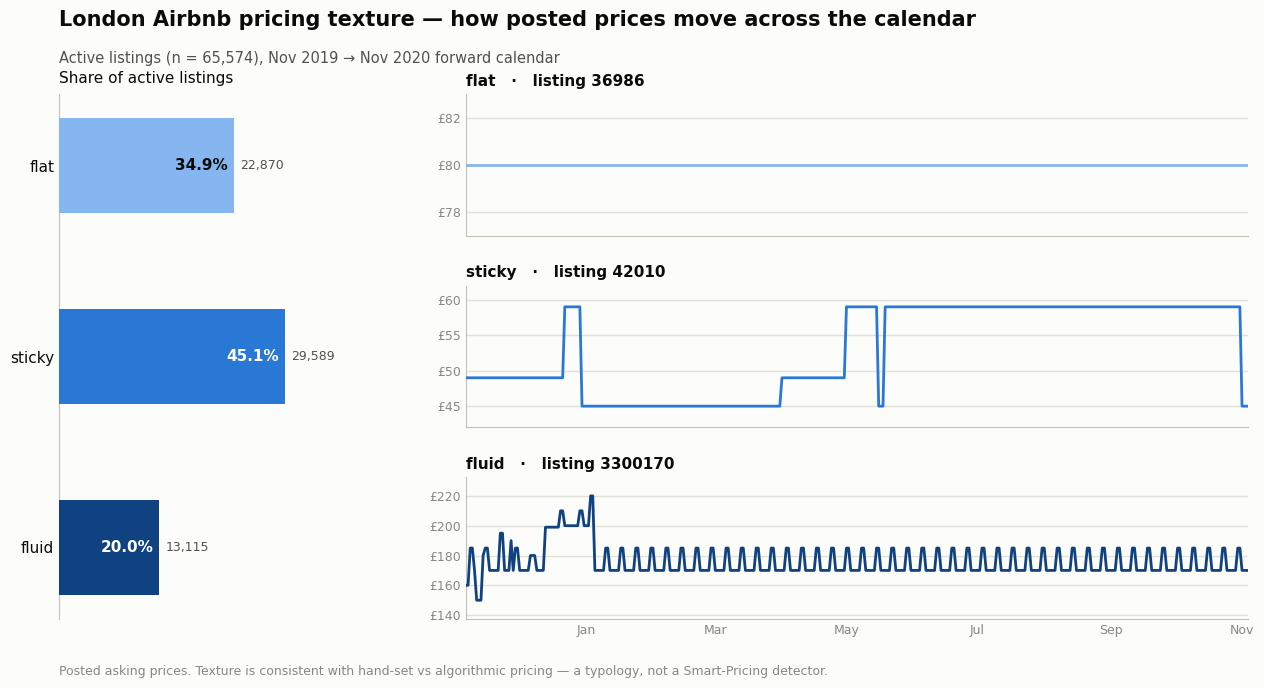

In [5]:
# ordinal blue ramp (flat→fluid = light→dark); chrome colours from Setup
COL = {"flat": "#86b6ef", "sticky": "#2a78d6", "fluid": "#104281"}

cal = load_calendar_slim()
fa["pmean"] = cal.groupby("listing_id")["price"].mean().reindex(fa.index)
shares = fa["texture"].value_counts(normalize=True).reindex(ORDER)
counts = fa["texture"].value_counts().reindex(ORDER)

def pick(mask, target_col, target_val):
    """Representative listing: closest to the bucket median of target_col, within a clean pool."""
    c = fa[mask & fa["pmean"].between(50, 200) & (fa["n_days"] >= 365)].copy()
    c["_d"] = (c[target_col] - target_val).abs()
    return int(c.reset_index().sort_values(["_d", "listing_id"]).iloc[0]["listing_id"])

ex = {
    "flat":   pick(fa.texture == "flat", "pmean", fa.loc[fa.texture == "flat", "pmean"].median()),
    "sticky": pick((fa.texture == "sticky") & fa.n_price_values.between(3, 6),
                   "cross_date_change_rate", fa.loc[fa.texture == "sticky", "cross_date_change_rate"].median()),
    "fluid":  pick((fa.texture == "fluid") & (fa.n_price_values >= 10) & fa.weekend_premium_raw.between(1.05, 1.20),
                   "cross_date_change_rate", fa.loc[fa.texture == "fluid", "cross_date_change_rate"].median()),
}
series = {t: cal[cal.listing_id == i].dropna(subset=["price"]).sort_values("date") for t, i in ex.items()}

gbp = FuncFormatter(lambda x, _: f"£{x:,.0f}")
fig = plt.figure(figsize=(13, 7), facecolor=SURF)
gs = fig.add_gridspec(3, 2, width_ratios=[1, 3], wspace=0.28, hspace=0.35,
                      left=0.06, right=0.975, top=0.86, bottom=0.11)

axs = fig.add_subplot(gs[:, 0], facecolor=SURF)
ypos = {"flat": 2, "sticky": 1, "fluid": 0}
lbl  = {"flat": INK, "sticky": "white", "fluid": "white"}
for t in ORDER:
    axs.barh(ypos[t], shares[t] * 100, height=0.5, color=COL[t], zorder=3)
    axs.text(shares[t]*100 - 1.2, ypos[t], f"{shares[t]*100:.1f}%", va="center", ha="right",
             color=lbl[t], fontsize=11, fontweight="bold")
    axs.text(shares[t]*100 + 1.2, ypos[t], f"{counts[t]:,}", va="center", ha="left", color=INK2, fontsize=9)
axs.set_yticks(list(ypos.values())); axs.set_yticklabels(list(ypos), color=INK, fontsize=11)
axs.set_xlim(0, 52); axs.set_xticks([])
axs.set_title("Share of active listings", color=INK, fontsize=11, loc="left", pad=8)
for sp in ["top", "right", "bottom"]: axs.spines[sp].set_visible(False)
axs.spines["left"].set_color(AXIS); axs.tick_params(length=0)

axes = [fig.add_subplot(gs[i, 1], facecolor=SURF) for i in range(3)]
for ax, t in zip(axes, ORDER):
    s = series[t]
    ax.plot(s["date"], s["price"], color=COL[t], linewidth=2, solid_joinstyle="round", solid_capstyle="round", zorder=3)
    lo, hi = s["price"].min(), s["price"].max(); pad = max((hi-lo)*0.18, 3)
    ax.set_ylim(lo-pad, hi+pad); ax.yaxis.set_major_formatter(gbp)
    ax.set_title(f"{t}   ·   listing {ex[t]}", color=INK, fontsize=11, loc="left", pad=6, fontweight="bold")
    ax.grid(axis="y", color=GRID, linewidth=1, zorder=0)
    for sp in ["top", "right"]: ax.spines[sp].set_visible(False)
    for sp in ["left", "bottom"]: ax.spines[sp].set_color(AXIS)
    ax.tick_params(colors=MUTED, length=0, labelsize=9); ax.set_xlim(s["date"].min(), s["date"].max())
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b"))
for ax in axes[:-1]: ax.tick_params(labelbottom=False)

fig.suptitle("London Airbnb pricing texture — how posted prices move across the calendar",
             x=0.06, ha="left", color=INK, fontsize=15, fontweight="bold")
fig.text(0.06, 0.905, "Active listings (n = 65,574), Nov 2019 → Nov 2020 forward calendar", ha="left", color=INK2, fontsize=10.5)
fig.text(0.06, 0.03, "Posted asking prices. Texture is consistent with hand-set vs algorithmic pricing — "
         "a typology, not a Smart-Pricing detector.", ha="left", color=MUTED, fontsize=9)

fig.savefig("../figures/texture_typology.png", dpi=170, facecolor=SURF)
plt.show()

**Reading (Layer 1)** — *derived (rule-based)*; posted prices only.

- **About a third of active listings post one price on every date** (flat, 34.9%). 45.1% vary but
  sit below the fluid cut (sticky), and the most dynamic fifth are fluid — 20.0% by construction
  (a top-quintile cut), so that share is a convention, not a finding.
- **The textures differ on features the index does not use.** Fluid listings are the least
  round-numbered: the median share of dates at a £5-multiple price is 0.40, against 0.91 for
  sticky and 1.00 for flat. A flat listing's share is 0 or 1, so the flat median only says that
  most flat listings (71%) post a round price; the means (0.71 / 0.62 / 0.48) fall in the same
  order. Fluid listings also carry a weekend premium: their median Fri/Sat price is 3.6% above
  their other nights, against about zero for sticky and exactly zero for flat. This check is only partly
  independent: a weekly Fri/Sat pattern changes the price about twice a week, which by itself
  raises the change rate the index ranks on. The calendar-update check that follows is the
  cleanest of the three. Their calendars
  were also touched more recently: 48% of fluid listings had the calendar updated on the scrape
  day, against 14% of sticky and 7% of flat ones: one more sign that fluid calendars are
  actively managed; whether by a person or a tool is unobserved.
- **Fluid pricing is 2.4 times as common among professional hosts' listings** (26.8% of their
  active listings vs 11.2% for casual hosts). *Associational:* professional hosts differ in many
  ways — location, property type and, plausibly, pricing tools, which the data do not record.

### Robustness — other samples

The same rule on two other samples: active listings using **available days only** (a blocked date
may carry a stale default price), and **all 85,068 listings**, dormant ones included. Each sample
is ranked within itself.

In [6]:
f_av = listing_price_features(available_only=True)
IDX_COLS = ["cross_date_change_rate", "n_price_values", "rel_range"]
prof_all = is_professional_host(listings.set_index("id"))
configs = {
    "active · all-days":       f.loc[f.index.isin(active_ids)],
    "active · available-only": f_av.loc[f_av.index.isin(active_ids)],
    "full 85,068 · all-days":  f,
}
rows = []
for name, frame in configs.items():
    frame = frame.dropna(subset=IDX_COLS)
    tex = classify_texture(frame)
    sh = tex.value_counts(normalize=True).reindex(ORDER)
    pm = prof_all.reindex(frame.index).astype(bool)
    ratio = (tex[pm] == "fluid").mean() / (tex[~pm] == "fluid").mean()
    rows.append([name, len(frame), sh["flat"], sh["sticky"], sh["fluid"], ratio])
pd.DataFrame(rows, columns=["config", "N", "flat", "sticky", "fluid", "prof_ratio"]).set_index("config").round(3)


,N,flat,sticky,fluid,prof_ratio
config,,,,,
active · all-days,65574,0.349,0.451,0.2,2.383
active · available-only,56154,0.405,0.395,0.2,2.323
"full 85,068 · all-days",85068,0.434,0.366,0.2,2.678


**Reading.** Fluid is 20% in every column *by construction* (the top-quintile rule), so its
stability says nothing. What moves is the flat share, 34.9% → 40.5% → 43.4%, as expected:
available days only leaves fewer dates per listing on which a price could differ, and the full
population adds dormant listings, whose calendars are mostly frozen. The professional association
holds in all three samples: fluid pricing is **2.3–2.7 times as common** among professional hosts'
listings as among casual hosts'. *The structure is stable; the level depends on the definition —
both are shown.*

## Layer 2 — Who prices dynamically?  *(associational)*

**Question.** Layer 1 found fluid pricing 2.4 times as common among professional hosts' listings.
But professional hosts also run different listings in different places. **How much of the
professional gap remains once what a listing is and where it is are held equal?**

**Two questions, one per part of the index.** 35% of active listings post one price on every
date, so the index has a spike at the bottom. The analysis therefore asks:

- **Q1 — do the listing's prices vary across dates at all?** Yes/no, a linear probability model;
  effects in percentage points. Flat vs varying is an observed fact, not a convention.
- **Q2 — among listings whose prices vary, how dynamic are they?** The Layer 1 dynamism index
  ×100; effects in index points.

**Traits, added in blocks** so the professional gap can be followed as more is held equal:
*who* (years on Airbnb at the scrape date, superhost), *what* (room type, number of guests) and
*where* (borough fixed effects) make the main model. A **second step** adds host settings —
instant booking, cancellation policy, minimum nights. They are chosen alongside pricing, so they
*go together with* dynamism rather than explain it. Left out on purpose: price level,
availability, review counts and `calendar_updated`, which are decided together with pricing or
nearly measure it.

**Standard errors are clustered by host:** a host's listings usually share one pricing approach,
so a host with 400 listings is closer to one decision than to 400. Sample: active listings minus
8 with no host record, so every model uses the same listings.

**Label: *associational*.** Pricing-tool adoption is unobserved and may drive both host type and
dynamic pricing; a single cross-section has no instrument, so this is description only. The Q2
outcome is the generated index: its measurement noise widens the intervals, and leaves the
estimates unbiased only if that noise is unrelated to the traits, which a rank-based index does
not guarantee.

In [7]:
# One row per active listing: the two outcomes, the traits, the host
fa["index"] = dynamism_index(fa)                      # the Layer 1 index, ranked within all active listings
lst = listings.set_index("id").loc[fa.index]
CANCEL = {"flexible": "flexible", "moderate": "moderate", "luxury_moderate": "moderate",
          "strict_14_with_grace_period": "strict", "strict": "strict", "super_strict_30": "super-strict",
          "super_strict_60": "super-strict", "luxury_super_strict_95": "super-strict"}


def labels(values, order):                            # a label column; the first level is the reference
    return pd.Categorical(values, categories=order)


def bins(x, edges, names, base):
    return labels(pd.cut(x, edges, labels=names).astype(str), [base] + [n for n in names if n != base])


l2 = pd.DataFrame({
    "varies_pp":       fa["varying"].astype(int) * 100,   # Q1 outcome, in percentage points
    "index_pts":       fa["index"] * 100,                 # Q2 outcome, in index points
    "professional":    fa["professional"].astype(int),
    "host_id":         lst["host_id"],
    "years_on_airbnb": (pd.Timestamp("2019-11-05") - pd.to_datetime(lst["host_since"])).dt.days / 365.25,
    "superhost":       parse_tf_bool(lst["host_is_superhost"]),
    "room_type":       labels(lst["room_type"], ["Entire home/apt", "Private room", "Hotel room", "Shared room"]),
    "guests":          bins(lst["accommodates"], [0, 1, 2, 4, 6, np.inf], ["1", "2", "3-4", "5-6", "7+"], base="2"),
    "borough":         lst["neighbourhood_cleansed"],
    "instant_book":    parse_tf_bool(lst["instant_bookable"]),
    "cancellation":    labels(lst["cancellation_policy"].map(CANCEL), ["flexible", "moderate", "strict", "super-strict"]),
    "min_nights":      bins(lst["minimum_nights"], [0, 1, 2, 6, 29, np.inf], ["1", "2", "3-6", "7-29", "30+"], base="1"),
    "host_size":       bins(lst["calculated_host_listings_count"], [0, 1, 4, 9, np.inf], ["1", "2-4", "5-9", "10+"], base="1"),
})
no_host = l2["years_on_airbnb"].isna()                # no host record: dropped from every model
l2 = l2[~no_host].astype({"superhost": int, "instant_book": int})
assert l2.notna().all().all()

q1 = l2.copy()                                        # Q1: all active listings
q2 = l2[l2["varies_pp"] == 100].copy()                # Q2: listings whose prices vary
for q in (q1, q2):                                    # for the check that counts each host once
    q["host_weight"] = 1 / q.groupby("host_id")["host_id"].transform("size")
print(f"dropped (no host record): {int(no_host.sum())} | Q1: {len(q1):,} listings, {q1['host_id'].nunique():,} hosts | "
      f"Q2: {len(q2):,} listings, {q2['host_id'].nunique():,} hosts")

dropped (no host record): 8 | Q1: 65,566 listings, 37,741 hosts | Q2: 42,699 listings, 23,065 hosts


In [8]:
# The professional gap as more is held equal: Raw -> + who -> + what -> + where (main) -> + settings
WHO, WHAT = "years_on_airbnb + superhost", "C(room_type) + C(guests)"
SETTINGS = "instant_book + C(cancellation) + C(min_nights)"
STEPS = {
    "Raw":            "professional",
    "+ who":          f"professional + {WHO}",
    "+ what":         f"professional + {WHO} + {WHAT}",
    "+ where (main)": f"professional + {WHO} + {WHAT} | borough",          # borough fixed effects
    "+ settings":     f"professional + {WHO} + {WHAT} + {SETTINGS} | borough",
}
QUESTIONS = {"Q1: prices vary at all (points)": ("varies_pp", q1),
             "Q2: how dynamic, if they vary (index points)": ("index_pts", q2)}
VCOV_HOST = {"CRV1": "host_id"}                        # clustered by host


def with_ci(r):
    return f"{r['Estimate']:+.1f}  [{r['2.5%']:+.1f}, {r['97.5%']:+.1f}]"


l2_fits = {(q, s): pf.feols(f"{y} ~ {rhs}", data=d, vcov=VCOV_HOST)
           for q, (y, d) in QUESTIONS.items() for s, rhs in STEPS.items()}
layer2 = pd.DataFrame({s: {q: with_ci(l2_fits[q, s].tidy().loc["professional"]) for q in QUESTIONS} for s in STEPS})
layer2                    # professional minus casual [95% CI], SEs clustered by host

,Raw,+ who,+ what,+ where (main),+ settings
Q1: prices vary at all (points),"+17.2 [+15.0, +19.5]","+17.1 [+14.9, +19.4]","+15.4 [+13.2, +17.6]","+13.1 [+10.8, +15.3]","+10.4 [+8.8, +12.0]"
"Q2: how dynamic, if they vary (index points)","+6.5 [+5.7, +7.4]","+6.3 [+5.4, +7.1]","+5.6 [+4.8, +6.4]","+4.7 [+3.9, +5.4]","+3.8 [+3.0, +4.5]"


In [9]:
# The other traits: main model, plus the settings from the second step
LABEL = {"professional": "Professional host (2+ listings)", "superhost": "Superhost",
         "years_on_airbnb": "Years on Airbnb (per year)",
         "C(room_type)[T.Private room]": "Private room (vs entire home)", "C(room_type)[T.Hotel room]": "Hotel room",
         "C(room_type)[T.Shared room]": "Shared room", "C(guests)[T.1]": "1 guest (vs 2)",
         "C(guests)[T.3-4]": "3-4 guests", "C(guests)[T.5-6]": "5-6 guests", "C(guests)[T.7+]": "7+ guests",
         "instant_book": "Instant booking (second step)",
         "C(cancellation)[T.moderate]": "Moderate cancellation (vs flexible)",
         "C(cancellation)[T.strict]": "Strict cancellation", "C(cancellation)[T.super-strict]": "Super-strict cancellation",
         "C(min_nights)[T.2]": "Minimum 2 nights (vs 1)", "C(min_nights)[T.3-6]": "Minimum 3-6 nights",
         "C(min_nights)[T.7-29]": "Minimum 7-29 nights", "C(min_nights)[T.30+]": "Minimum 30+ nights"}
detail = {}
for q in QUESTIONS:
    main, sett = l2_fits[q, "+ where (main)"].tidy(), l2_fits[q, "+ settings"].tidy()
    detail[q] = pd.concat([main, sett.loc[~sett.index.isin(main.index)]]).apply(with_ci, axis=1)
display(pd.DataFrame(detail).reindex(list(LABEL)).rename(index=LABEL))

# Checks: each host counted once; host size in tiers; how much the traits explain
for q, (y, d) in QUESTIONS.items():
    rhs = STEPS["+ where (main)"]
    once = pf.feols(f"{y} ~ {rhs}", data=d, vcov=VCOV_HOST, weights="host_weight")
    tiers = pf.feols(f"{y} ~ {rhs.replace('professional', 'C(host_size)')}", data=d, vcov=VCOV_HOST).coef()
    print(f"{q}\n  each host counted once: {with_ci(once.tidy().loc['professional'])}"
          "\n  by host size, vs 1 listing: "
          + ", ".join(f"{k.split('T.')[1][:-1]} {v:+.1f}" for k, v in tiers.items() if "host_size" in k)
          + f"\n  variation explained by the main model: {l2_fits[q, '+ where (main)']._r2:.0%}")

# How much of the index is shared within a host (hosts with 2+ active listings)
multi = q1[q1.groupby("host_id")["host_id"].transform("size") >= 2]
between = ((multi.groupby("host_id")["index_pts"].transform("mean") - multi["index_pts"].mean()) ** 2).sum()
share = between / ((multi["index_pts"] - multi["index_pts"].mean()) ** 2).sum()
chance = (multi["host_id"].nunique() - 1) / (len(multi) - 1)
print(f"hosts with 2+ active listings ({multi['host_id'].nunique():,} hosts, {len(multi):,} listings): "
      f"the host's average explains {share:.0%} of the variation in the index (chance level {chance:.0%})")

,Q1: prices vary at all (points),"Q2: how dynamic, if they vary (index points)"
Coefficient,,
Professional host (2+ listings),"+13.1 [+10.8, +15.3]","+4.7 [+3.9, +5.4]"
Superhost,"+11.2 [+9.3, +13.1]","-1.1 [-1.9, -0.3]"
Years on Airbnb (per year),"-1.0 [-1.4, -0.6]","-0.8 [-1.0, -0.5]"
Private room (vs entire home),"-3.2 [-5.0, -1.4]","-2.8 [-3.8, -1.8]"
Hotel room,"+13.6 [+8.0, +19.2]","+3.4 [-2.7, +9.4]"
Shared room,"-1.3 [-9.3, +6.7]","-1.1 [-4.9, +2.7]"
1 guest (vs 2),"-12.3 [-14.0, -10.7]","-3.8 [-4.5, -3.0]"
3-4 guests,"+5.6 [+4.3, +6.9]","+3.0 [+2.3, +3.7]"
5-6 guests,"+7.2 [+5.1, +9.2]","+4.9 [+4.0, +5.9]"


Q1: prices vary at all (points)
  each host counted once: +9.1  [+8.1, +10.0]
  by host size, vs 1 listing: 2-4 +8.9, 5-9 +20.0, 10+ +16.5
  variation explained by the main model: 9%
Q2: how dynamic, if they vary (index points)
  each host counted once: +1.0  [+0.7, +1.4]
  by host size, vs 1 listing: 2-4 +1.8, 5-9 +5.9, 10+ +7.9
  variation explained by the main model: 16%
hosts with 2+ active listings (8,245 hosts, 36,070 listings): the host's average explains 77% of the variation in the index (chance level 23%)


**Reading (Layer 2)** — *associational*; posted prices only.

- **Most of the professional gap remains after controlling for the recorded traits.** Before any
  controls, professional hosts' listings are 17.2 points more likely to vary their prices at all.
  With years on Airbnb and superhost status, room type and size, and borough held equal, the gap
  is still 13.1 points (95% CI 10.8 to 15.3). Room type, size and borough are coarse controls, so
  unrecorded differences between properties can remain. Among listings that vary, it goes from 6.5
  to 4.7 index points. About three quarters of the gap survives.
- **Host settings take a further bite.** Adding instant booking, cancellation policy and minimum
  nights lowers the gap to 10.4 points and 3.8 index points. Instant-bookable listings and those
  with moderate or strict cancellation are more likely to vary prices; long-stay listings (7+
  minimum nights) much less. These settings are chosen alongside pricing: they go together with
  dynamism, they do not explain it.
- **It is a big-operator gap.** Compared with single-listing hosts, listings of hosts with 2-4
  listings are 8.9 points more likely to vary prices, 5-9 listings 20.0 and 10+ listings 16.5;
  among listings that vary, the index gap rises with host size (+1.8, +5.9, +7.9). Counting each
  host once, which lets the many small multi-listing hosts dominate, the professional gap is
  +9.1 points and +1.0 index points.
- **Other traits.** Superhosts are more likely to vary prices at all (+11.2 points) but are not
  more dynamic when they do (−1.1 index points). Larger listings and hotel rooms vary more,
  single-guest listings less, and each extra year on Airbnb goes with about one point less.
- **Recorded traits explain little; listings of the same host price alike.** The main model
  accounts for 9% of the variation in whether prices vary and 16% in how dynamic they are. Among
  hosts with 2+ active listings, the host's average accounts for 77% of the variation in the
  index, where chance would give about 23%. The two numbers are not a like-for-like contest: the
  host average also carries what a host's listings share (borough, property type) and covers
  multi-listing hosts only. Together they say pricing style clusters by host far more than the
  recorded traits predict. What those hosts do differently, pricing tools included, is not in
  the data.

## Layer 3 — Within-listing calendar differences  *(within-listing difference)*

**Question.** Within the *same listing*, how much higher is the posted price on Friday/Saturday
nights, on bank holidays, and in the festive week than on that listing's other nights of the
same month?

**Model.** `log(price) ~ is_weekend + is_bank_holiday + festive_week + C(year_month)` with
**listing fixed effects**, estimated with `pyfixest`. The timing columns come from
`src/timing.py::timing_columns` (*derived, rule-based*): Friday and Saturday nights; the 8 England
bank holidays in the window; the festive week 24 Dec – 1 Jan (both ends included); and 13
year-month levels, so the window's two Novembers stay separate.

- **Samples:** active listings, all calendar days (primary); available days only (robustness).
- **Standard errors** are clustered two ways, by host and by week. A host's listings often
  follow one pricing rule, so they move together even on different dates; neighbouring dates
  share shocks, such as a busy week in London. Host clusters contain listing clusters and week
  clusters contain date clusters, so both kinds of dependence are allowed for. The timing columns
  vary only by date, so the effective sample for these effects is dates, not the 24M rows; naive
  standard errors would be far too small. The festive week is a single nine-day episode, so its
  interval stays optimistic under any clustering.
- **Differences** are reported as exp(b) − 1, in %.

**Label: *within-listing difference*** — the listing fixed effects remove everything about a
listing that does not vary across dates, and the year-month effects remove what all listings
share in each month. What remains is a clean comparison of the same listing's prices across
dates, not the effect of an intervention: "being a Friday night" bundles everything that comes
with Fridays, from demand to local events, and the festive week is a single nine-day episode. **No lead-time claims:** one snapshot cannot separate lead time from
seasonality; the year-month effects absorb both and are not interpreted. All prices are posted
(asking) prices.

In [10]:
# Regression panel: active listings x calendar days with a posted price (reuses `cal` from above)
panel = cal.loc[cal["listing_id"].isin(active_ids) & cal["price"].notna(),
                ["listing_id", "date", "available", "price"]].reset_index(drop=True)
del cal                                                     # free ~0.8 GB before estimation
panel = panel.join(timing_columns(panel["date"]))
panel["log_price"] = np.log(panel["price"])
TIMING = ["is_weekend", "is_bank_holiday", "festive_week"]
panel[TIMING] = panel[TIMING].astype("int8")                # 0/1 -> clean coefficient names
panel["host_id"] = panel["listing_id"].map(listings.set_index("id")["host_id"])      # cluster: host
panel["week"] = ((panel["date"] - pd.Timestamp("2019-11-04")).dt.days // 7).astype("int16")  # cluster: Monday-start week

FML  = "log_price ~ is_weekend + is_bank_holiday + festive_week + C(year_month) | listing_id"
VCOV = {"CRV1": "host_id+week"}                             # two-way clustered: host and week


def fit_lean(fml, data):
    """Fit with pyfixest and keep only the results. Even with lean=True, pyfixest 0.60 keeps a
    cache of the demeaned data and a copy of the design matrix — about 6 GB per full-panel fit
    here — and neither is used below (only coefficients and the clustered covariance matrix are).
    Dropping them stops the fits piling up in memory; the estimates are unchanged."""
    fit = pf.feols(fml, data=data, vcov=VCOV, lean=True, store_data=False)
    fit._lookup_demeaned_data = {}
    fit.__dict__.pop("_X_untransformed", None)
    return fit


print(f"panel: {len(panel):,} listing-days | {panel['listing_id'].nunique():,} listings | "
      f"{panel['date'].nunique()} dates | available days {int(panel['available'].sum()):,}")

panel: 23,933,818 listing-days | 65,574 listings | 366 dates | available days 10,106,832


**Check on a 5,000-listing sample** (also the dry run for memory and runtime). The same model is
fitted twice: with `pyfixest`, and by hand — every column demeaned within listing in DuckDB SQL
(`x - AVG(x) OVER (PARTITION BY listing_id)`), then plain least squares. By the
Frisch–Waugh–Lovell theorem the two must give identical coefficients. The last line shows how
much larger the two-way clustered standard errors are than naive ones.

In [11]:
smp = panel[panel["listing_id"].isin(active_ids.sample(5000, random_state=RANDOM_SEED))].copy()
fit_smp = pf.feols(FML, data=smp, vcov=VCOV)

# The same regression by hand: demean within listing in SQL, then least squares
con = duckdb.connect()
con.register("smp", smp)
levels = list(smp["year_month"].cat.categories[1:])         # 201911 is the base level
xcols = TIMING + [f"ym_{v}" for v in levels]
dummies = ",\n         ".join(f"(year_month = {v})::DOUBLE AS ym_{v}" for v in levels)
demeaned = ",\n       ".join(f"{c} - AVG({c}) OVER w AS {c}" for c in ["log_price"] + xcols)
d = con.sql(f"""
WITH x AS (
  SELECT listing_id, log_price,
         is_weekend::DOUBLE AS is_weekend, is_bank_holiday::DOUBLE AS is_bank_holiday,
         festive_week::DOUBLE AS festive_week,
         {dummies}
  FROM smp)
SELECT {demeaned}
FROM x
WINDOW w AS (PARTITION BY listing_id)
""").df()
b_sql, *_ = np.linalg.lstsq(d[xcols].to_numpy(), d["log_price"].to_numpy(), rcond=None)

gap = np.abs(fit_smp.coef().to_numpy() - b_sql).max()
print(f"sample: {len(smp):,} listing-days | max |pyfixest - SQL| over {len(b_sql)} coefficients: {gap:.1e}")
assert gap < 1e-8
se_ratio = fit_smp.se()[TIMING] / fit_smp.vcov("iid").se()[TIMING]
print("two-way clustered SE / naive SE:", se_ratio.round(1).to_dict())

sample: 1,825,002 listing-days | max |pyfixest - SQL| over 15 coefficients: 1.2e-12
two-way clustered SE / naive SE: {'is_weekend': 8.4, 'is_bank_holiday': 4.6, 'festive_week': 22.0}


In [12]:
# Full estimation (fit_lean is defined with the panel above). SEs are computed at fit time.
fit_all = fit_lean(FML, panel)

avail = panel[panel["available"]].copy()
avail["year_month"] = avail["year_month"].cat.remove_unused_categories()
n_single = int((avail.groupby("listing_id").size() == 1).sum())
with warnings.catch_warnings():             # pyfixest warns when it drops them; reported below instead
    warnings.filterwarnings("ignore", message=r"\d+ singleton fixed effect")
    fit_av = fit_lean(FML, avail)
print(f"available days only: {n_single} listings with a single available day are dropped "
      "(a listing fixed effect needs 2+ days)")

available days only: 595 listings with a single available day are dropped (a listing fixed effect needs 2+ days)


In [13]:
def pct(x):
    return (np.exp(x) - 1) * 100                            # log points -> % effect

def listings_used(frame):                                   # pyfixest drops single-day listings
    return int((frame.groupby("listing_id").size() >= 2).sum())

LABELS = {"is_weekend": "Fri/Sat night", "is_bank_holiday": "Bank holiday",
          "festive_week": "Festive week (24 Dec – 1 Jan)"}
cols = {}
for name, fit, frame in [("All days (primary)", fit_all, panel), ("Available days only", fit_av, avail)]:
    t = fit.tidy().loc[TIMING]
    cells = {LABELS[k]: f"{pct(r['Estimate']):+.1f}%  [{pct(r['2.5%']):+.1f}, {pct(r['97.5%']):+.1f}]"
             for k, r in t.iterrows()}
    cells["Listing-days"] = f"{fit._N:,}"
    cells["Listings"] = f"{listings_used(frame):,}"
    cols[name] = cells
layer3 = pd.DataFrame(cols)          # effect % [95% CI], two-way clustered (host, week)
display(layer3)

coefs = pd.concat({"all days": fit_all.tidy().loc[TIMING, ["Estimate", "Std. Error"]],
                   "available only": fit_av.tidy().loc[TIMING, ["Estimate", "Std. Error"]]}, axis=1)
coefs.round(4)                       # raw coefficients (log points) = the reproduction targets

,All days (primary),Available days only
Fri/Sat night,"+2.4% [+2.1, +2.7]","+3.0% [+2.6, +3.4]"
Bank holiday,"-0.4% [-1.1, +0.3]","-0.5% [-1.4, +0.5]"
Festive week (24 Dec – 1 Jan),"+11.4% [+7.6, +15.2]","+16.1% [+10.8, +21.6]"
Listing-days,"23,933,818","10,106,237"
Listings,"65,574","56,154"


all days            available only           
                Estimate Std. Error       Estimate Std. Error
Coefficient                                                  
is_weekend        0.0238     0.0014         0.0299     0.0019
is_bank_holiday  -0.0041     0.0034        -0.0046     0.0047
festive_week      0.1077     0.0170         0.1492     0.0231

**Reading** — *within-listing difference*; posted prices only.

- **Fri/Sat nights: +2.4%** (95% CI +2.1 to +2.7) against the same listing's other nights in
  the same month, and **+3.0%** on available days only: same sign, similar size in both
  samples. It is an average over all active listings, including the 35% flat ones whose
  difference is zero by construction — consistent with Layer 1, where the fluid group's median
  raw weekend premium is +3.6%.
- **Festive week: +11.4%** (CI +7.6 to +15.2); **+16.1%** on available days only.
- **Bank holidays: no detectable extra premium** (−0.4%, CI −1.1 to +0.3; −0.5% on available
  days). The interval includes zero, which does not prove the premium is zero; it bounds it,
  ruling out an extra premium above about 0.3%. Read it with
  the overlaps: three of the eight holidays (25–26 Dec, 1 Jan) sit inside the festive week, so
  their premium loads on `festive_week` (Christmas Day's combined effect is +10.9%); Good Friday
  and VE Day fall on Fridays, so the weekend term takes their Friday premium. And the flag marks
  each holiday's *own night* — for a Monday bank holiday, the extra long-weekend night is the
  Sunday before, which this flag does not mark. So this flag shows no detectable extra premium on the
  holiday night itself; the long-weekend night is checked separately below (none detectable either).
- **Uncertainty.** Two-way clustering matters: in the 5,000-listing check the clustered standard
  errors are 5–22× the naive ones. The bank-holiday and festive effects rest on only 8 and 9
  dates, so their intervals are approximate.
- **Available-only effects are larger.** Two readings, neither tested here. Blocked dates may
  carry an untouched default price, which dilutes the contrast when all days are used. And the
  available sample is selected on demand: weekend and festive nights still open in November lean
  toward the unsold, possibly higher-priced ones. So this column checks sign and rough size; it
  is not a cleaner estimate.

### Who shows larger calendar premiums? Professional vs casual hosts  *(associational moderation)*

**Question.** Do listings run by **professional hosts** (2+ London listings) post bigger calendar
premiums than listings run by **casual hosts** (1 listing)?

**Model.** The main model above plus timing × professional interactions:
`log(price) ~ timing + timing:professional + C(year_month) | listing_id`. The professional main
effect is absorbed by the listing fixed effects; each interaction is the professional-minus-casual
gap. Same sample (active listings, all days) and two-way clustered standard errors. As a check,
the main model is also fitted separately for each group, which lets each group have its own
month-by-month seasonality.

**Label.** Each group's within-listing difference is measured the same way; the comparison
*between* groups is **associational** — professional hosts differ in many ways (location,
property type, pricing tools), and hosts self-select. *Which group shows the larger difference
is descriptive.*

Not split by texture: flat listings post one price on every date, so their calendar premium is
zero by construction (Layer 1 shows the raw version). "Professional" counts all of a host's London
listings, dormant ones included — for 858 active listings (2.3% of the professional group) the
host has only one active listing.

In [14]:
# Free the check sample and the available-days sample (the next fits are the largest here)
con.close()
del avail, smp, d, con, fit_smp

# Operator type: professional = host with 2+ London listings (the Layer-1 default)
prof = is_professional_host(listings.set_index("id"))
panel["professional"] = panel["listing_id"].map(prof).astype("int8")
n_grp = panel.groupby("listing_id")["professional"].first().value_counts()
print(f"active listings: professional {n_grp[1]:,} | casual {n_grp[0]:,}")

# One model with interactions: each timing:professional term is the professional-minus-casual gap
INTER = [f"{v}:professional" for v in TIMING]
FML_C3 = "log_price ~ " + " + ".join(TIMING + INTER) + " + C(year_month) | listing_id"
fit_c3 = fit_lean(FML_C3, panel)

active listings: professional 36,928 | casual 28,646


In [15]:
# Each group's effect from the interaction model: casual = b, professional = b + gap
b, tid = fit_c3.coef(), fit_c3.tidy()
V = pd.DataFrame(fit_c3._vcov, index=b.index, columns=b.index)          # pyfixest keeps the matrix in _vcov
crit = float(((tid["97.5%"] - tid["Estimate"]) / tid["Std. Error"]).iloc[0])   # pyfixest's own critical value
rows = []
for v in TIMING:
    g = f"{v}:professional"
    for grp, e_, var in [("casual", b[v], V.loc[v, v]),
                         ("professional", b[v] + b[g], V.loc[v, v] + V.loc[g, g] + 2 * V.loc[v, g])]:
        rows.append((v, grp, e_, e_ - crit * np.sqrt(var), e_ + crit * np.sqrt(var)))
rows += [(v, "all", r["Estimate"], r["2.5%"], r["97.5%"]) for v, r in fit_all.tidy().loc[TIMING].iterrows()]
est = pd.DataFrame(rows, columns=["effect", "group", "b", "lo", "hi"])
est[["b", "lo", "hi"]] = pct(est[["b", "lo", "hi"]])                    # log points -> % effect

def fmt(r):
    return f"{r['b']:+.1f}%  [{r['lo']:+.1f}, {r['hi']:+.1f}]"

tab = {}
for v in TIMING:
    e = est[est["effect"] == v].set_index("group")
    p = tid.loc[f"{v}:professional", "Pr(>|t|)"]
    tab[LABELS[v]] = {"All listings": fmt(e.loc["all"]), "Casual (1)": fmt(e.loc["casual"]),
                      "Professional (2+)": fmt(e.loc["professional"]),
                      "Gap, pro − casual": f"{e.loc['professional', 'b'] - e.loc['casual', 'b']:+.1f} pts  "
                                           + ("(p < 0.001)" if p < 0.001 else f"(p = {p:.2f})")}
c3_table = pd.DataFrame(tab).T       # effect % [95% CI], two-way clustered (host, week)
display(c3_table)

# Check: the main model fitted separately per group (each group gets its own year-month effects)
split = {}
for grp, val in [("Casual (1)", 0), ("Professional (2+)", 1)]:
    fs = fit_lean(FML, panel[panel["professional"] == val])
    split[grp] = pct(fs.coef()[TIMING]).rename(LABELS)
pd.DataFrame(split).round(1)         # % effects, separate fits — compare with the table above

,All listings,Casual (1),Professional (2+),"Gap, pro − casual"
Fri/Sat night,"+2.4% [+2.1, +2.7]","+1.6% [+1.5, +1.8]","+3.0% [+2.6, +3.5]",+1.4 pts (p < 0.001)
Bank holiday,"-0.4% [-1.1, +0.3]","-0.4% [-1.0, +0.1]","-0.4% [-1.4, +0.6]",+0.0 pts (p = 0.98)
Festive week (24 Dec – 1 Jan),"+11.4% [+7.6, +15.2]","+7.5% [+5.5, +9.5]","+14.5% [+9.2, +20.1]",+7.0 pts (p < 0.001)


,Casual (1),Professional (2+)
Coefficient,,
Fri/Sat night,1.6,3.0
Bank holiday,-0.2,-0.6
Festive week (24 Dec – 1 Jan),6.4,15.4


In [16]:
# Long-weekend check: the main model plus the night before each Monday/Friday bank holiday (5 nights)
panel["long_weekend_night"] = panel["long_weekend_night"].astype("int8")
FML_LW = "log_price ~ is_weekend + is_bank_holiday + festive_week + long_weekend_night + C(year_month) | listing_id"
fit_lw = fit_lean(FML_LW, panel)
r = fit_lw.tidy().loc["long_weekend_night"]
print(f"long-weekend night: {pct(r['Estimate']):+.1f}%  [{pct(r['2.5%']):+.1f}, {pct(r['97.5%']):+.1f}]")
shift = (fit_lw.coef()[TIMING] - fit_all.coef()[TIMING]).abs().max()
print(f"largest change in the main-model coefficients when the flag is added: {shift:.4f} log points")

long-weekend night: +0.1%  [-0.1, +0.3]
largest change in the main-model coefficients when the flag is added: 0.0000 log points


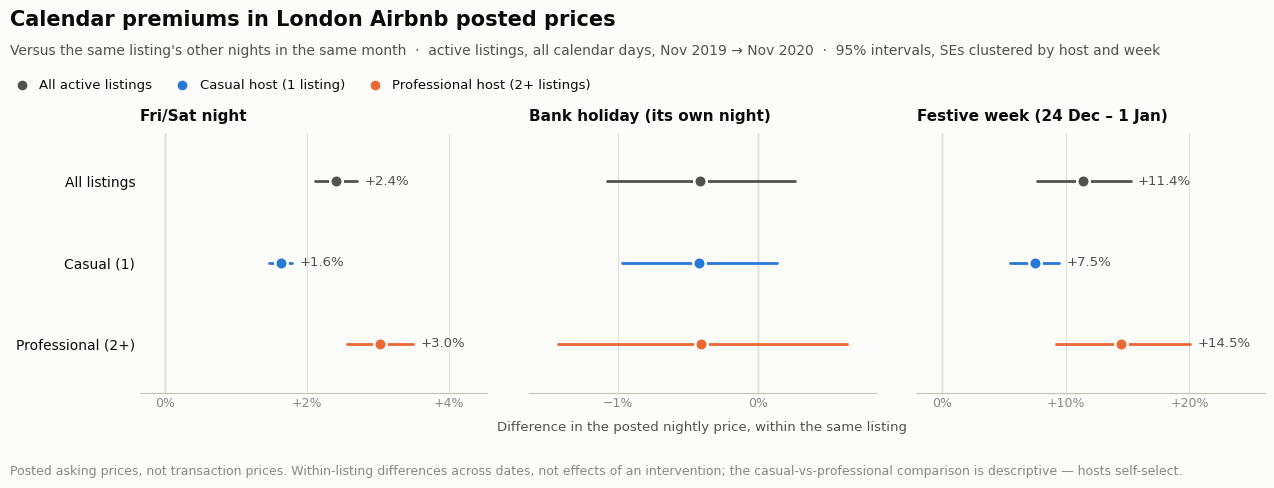

In [17]:
# neutral reference + two categorical colours (colour-blind safe, light surface)
GCOL = {"all": INK2, "casual": "#2a78d6", "professional": "#eb6834"}
GROUPS = {"all": "All active listings", "casual": "Casual host (1 listing)",
          "professional": "Professional host (2+ listings)"}
ROWS = {"all": "All listings", "casual": "Casual (1)", "professional": "Professional (2+)"}
PANELS = {"is_weekend": "Fri/Sat night", "is_bank_holiday": "Bank holiday (its own night)",
          "festive_week": "Festive week (24 Dec – 1 Jan)"}
LABELLED = {"is_weekend", "festive_week"}                                  # value labels only where they carry the story
ypos = {"all": 2, "casual": 1, "professional": 0}

fig, axes = plt.subplots(1, 3, figsize=(13, 5.0), sharey=True, facecolor=SURF,
                         gridspec_kw={"wspace": 0.12, "left": 0.12, "right": 0.985, "top": 0.72, "bottom": 0.2})
for ax, (eff, title) in zip(axes, PANELS.items()):
    ax.set_facecolor(SURF)
    e = est[est["effect"] == eff].set_index("group")
    span = max(e["hi"].max(), 0) - min(e["lo"].min(), 0)
    right_pad = 0.30 if eff in LABELLED else 0.10
    ax.set_xlim(min(e["lo"].min(), 0) - 0.10 * span, max(e["hi"].max(), 0) + right_pad * span)
    ax.axvline(0, color=AXIS, linewidth=1, zorder=1)
    for g, y in ypos.items():
        r = e.loc[g]
        ax.plot([r["lo"], r["hi"]], [y, y], color=GCOL[g], linewidth=2, solid_capstyle="round", zorder=3)
        ax.plot(r["b"], y, "o", markersize=9, color=GCOL[g], markeredgecolor=SURF, markeredgewidth=1.8, zorder=4)
        if eff in LABELLED:
            ax.text(r["hi"] + 0.03 * span, y, f"{r['b']:+.1f}%", va="center", ha="left", color=INK2, fontsize=9.5)
    ax.set_title(title, color=INK, fontsize=11, loc="left", pad=8, fontweight="bold")
    ax.xaxis.set_major_locator(MaxNLocator(nbins=4, steps=[1, 2, 5, 10], integer=True))
    ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: "0%" if abs(v) < 1e-9 else f"{v:+.0f}%".replace("-", "−")))
    ax.grid(axis="x", color=GRID, linewidth=0.8, zorder=0)
    ax.tick_params(colors=MUTED, length=0, labelsize=9)
    for sp in ["top", "right", "left"]:
        ax.spines[sp].set_visible(False)
    ax.spines["bottom"].set_color(AXIS)
axes[0].set_yticks(list(ypos.values()))
axes[0].set_yticklabels([ROWS[g] for g in ypos], color=INK, fontsize=10)
axes[0].set_ylim(-0.6, 2.6)
axes[1].set_xlabel("Difference in the posted nightly price, within the same listing", color=INK2, fontsize=9.5, labelpad=8)

fig.suptitle("Calendar premiums in London Airbnb posted prices", x=0.02, ha="left", y=0.965,
             color=INK, fontsize=15, fontweight="bold")
fig.text(0.02, 0.875, "Versus the same listing's other nights in the same month  ·  active listings, all calendar days, "
         "Nov 2019 → Nov 2020  ·  95% intervals, SEs clustered by host and week", ha="left", color=INK2, fontsize=10)
handles = [Line2D([], [], marker="o", linestyle="none", markersize=8, color=GCOL[g],
                  markeredgecolor=SURF, label=GROUPS[g]) for g in ypos]
fig.legend(handles=handles, loc="upper left", bbox_to_anchor=(0.015, 0.85), ncol=3, frameon=False,
           fontsize=9.5, labelcolor=INK, handlelength=1.0, columnspacing=1.8)
fig.text(0.02, 0.035, "Posted asking prices, not transaction prices. Within-listing differences across dates, not effects of an "
         "intervention; the casual-vs-professional comparison is descriptive — hosts self-select.",
         ha="left", color=MUTED, fontsize=9)
fig.savefig("../figures/weekend_holiday_fe.png", dpi=170, facecolor=SURF)
plt.show()

**Reading** — an *associational* comparison of *within-listing differences*; posted prices only.

- **Professional hosts' listings show about twice the calendar premium.** Fri/Sat nights: **+3.0%** for
  professional hosts vs **+1.6%** for casual hosts (gap +1.4 points, p < 0.001). Festive week:
  **+14.5%** vs **+7.5%** (p < 0.001). This fits Layer 1, where fluid pricing is 2.4× as common
  among professional hosts.
- **Bank holidays: no detectable extra premium in either group** (−0.4% each; gap p = 0.98).
- **No detectable extra premium on the long-weekend night either** (+0.1%, CI −0.1 to +0.3): the
  Sunday before a Monday bank holiday or the Thursday before a Friday one. Together with the
  holiday night, neither night shows a detectable extra premium; an interval that includes zero
  does not prove the premium is zero, it bounds it. (Five dates, so the interval is approximate;
  adding the flag leaves the main-model coefficients unchanged.)
- **Robust to seasonality differences.** Fitting each group separately — so each gets its own
  month-by-month pattern — gives the same picture: weekend +1.6% vs +3.0%, festive +6.4% vs +15.4%.
- **What this does not say.** *Which group shows the larger difference is descriptive.*
  Professional hosts differ in location, property type and, plausibly, pricing tools,
  so the gap is not the effect of "being professional".

## Limitations

- **Posted, not transacted.** Every price is an asking price as of November 2019. Nothing here
  measures what guests paid, how many nights were booked, or demand.
- **Blocked is not booked.** The availability flag marks a date closed without saying why, so the
  available-days sample means "open on the scrape date", not "unsold". Two untested readings of why
  the available-days effects are larger: blocked dates may carry an untouched default price, and
  the dates still open are selected on demand (weekend and festive nights that remain unsold
  may be the higher-priced ones).
- **One snapshot, one market.** London, November 2019. The data show the price surface across
  forward dates, not how often hosts revise prices, so lead time cannot be separated from
  seasonality; the year-month effects absorb both and are not interpreted.
- **Pre-pandemic plans.** The window runs to November 2020, but every price was posted in
  November 2019, before COVID-19: the surface records plans, not what happened in 2020.
- **Few treated dates.** The bank-holiday, festive-week and long-weekend effects rest on 8, 9 and
  5 dates, so their intervals are approximate even with two-way clustering.
- **Conventions, not discoveries.** The fluid cut (top quintile of the dynamism index) is a chosen
  convention, and the index's three components are highly correlated: it measures essentially one
  "price movement" dimension, three ways (`src/pricing.py::dynamism_index`).
- **"Professional" is a host-size label.** It counts all of a host's listings in the London file,
  dormant ones included, and professional hosts differ in many unobserved ways — plausibly
  including pricing tools — so every professional-vs-casual result is associational.
- **Layer 2 describes, it does not explain.** The traits in the data account for little of who
  prices dynamically; what separates dynamic from static pricers — tools, time, attention — is
  mostly unrecorded.

## Next steps

- **A borough map of dynamism** — the median index by borough.
- **`adjusted_price` rerun** of the Layer 3 models (it differs from `price` on 0.65% of rows).
- **Named events** — Wimbledon, Notting Hill Carnival, the London Marathon — as extra timing flags.
- **Professional-threshold robustness:** the professional-vs-casual comparison with the bar at 3,
  5 and 10 listings.
- **Wild-cluster bootstrap** intervals for the effects that rest on few dates (bank holidays,
  festive week, long-weekend nights).